In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn import datasets
import seaborn as sns

In [5]:
df = sns.load_dataset("titanic")

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
from sklearn.impute import SimpleImputer

In [9]:
im = SimpleImputer()

In [16]:
categorical = df.select_dtypes(include="object").columns
numerical = df.select_dtypes(include = "number").columns

In [17]:
im = SimpleImputer(strategy = "most_frequent")
df[categorical] = im.fit_transform(df[categorical])

In [18]:
im = SimpleImputer(strategy = "mean")
df[numerical] = im.fit_transform(df[numerical])

In [19]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

In [20]:
df.dtypes

survived        float64
pclass          float64
sex              object
age             float64
sibsp           float64
parch           float64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [21]:
features = ["sex","age","embarked","pclass","fare"]
target = ["survived"]

In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
le = LabelEncoder()

In [24]:
df["sex"] = le.fit_transform(df["sex"])

In [25]:
df["embarked"] = le.fit_transform(df["embarked"])

In [64]:
x = df[features]
y = df["survived"]

In [65]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [66]:
from sklearn.tree import DecisionTreeClassifier

In [82]:
model = DecisionTreeClassifier(max_depth = 4)

In [83]:
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4)

In [84]:
y_pred = model.predict(x_test)
y_pred_train = model.predict(x_train)

In [85]:
from sklearn.metrics import accuracy_score

In [86]:
accuracy_score(y_test,y_pred)

0.7988826815642458

In [87]:
accuracy_score(y_pred_train,y_train)

0.8398876404494382

In [73]:
from sklearn.tree import plot_tree

In [74]:
import matplotlib.pyplot as plt

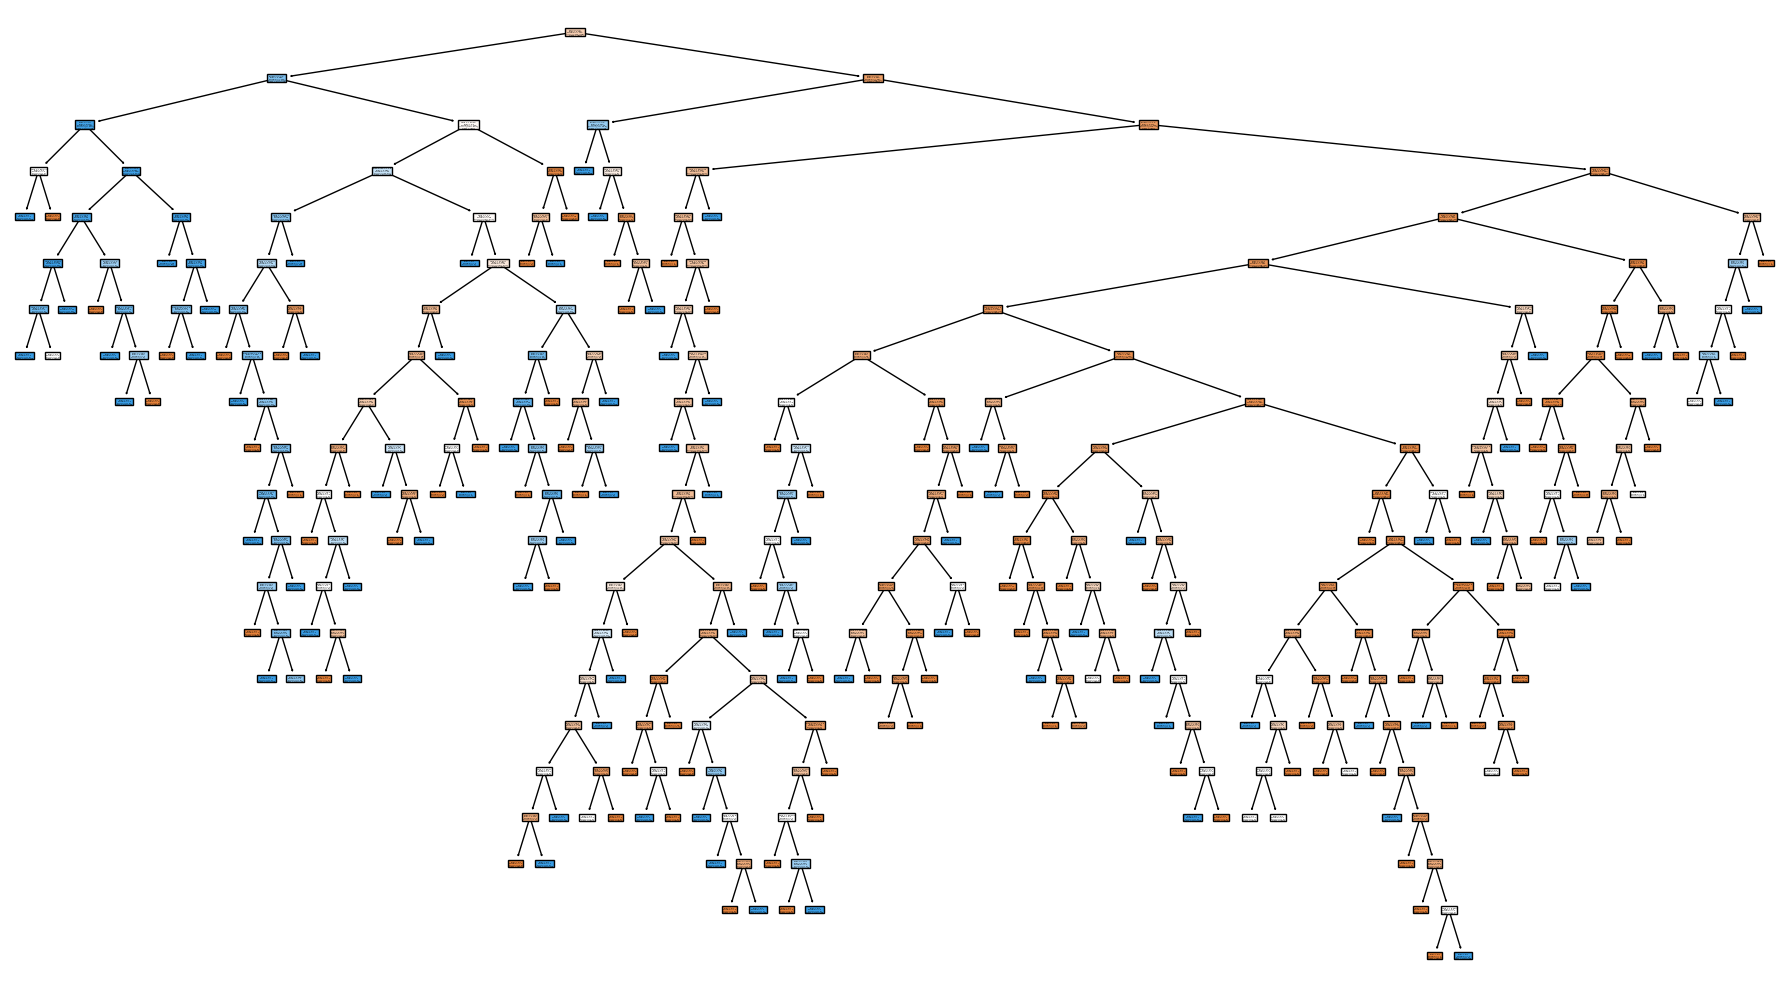

In [75]:
plt.figure(figsize = (18,10))

plot_tree(
    model,
    feature_names = x.columns,
    class_names = ["died","survived"],
    filled = True
)
plt.tight_layout()

In [88]:
from sklearn.ensemble import RandomForestClassifier

In [89]:
model_r = RandomForestClassifier(n_estimators = 201,oob_score = True,max_depth = 4)

In [90]:
model_r.fit(x_train,y_train)

RandomForestClassifier(max_depth=4, n_estimators=201, oob_score=True)

In [91]:
y_pred = model_r.predict(x_test)
y_pred_train = model_r.predict(x_train)

In [92]:
accuracy_score(y_pred,y_test)

0.8100558659217877

In [93]:
print(model_r.oob_score_)

0.827247191011236
